# Uber Trips Analysis — End-to-End Data Analyst Project

**Dataset:** `uber_trips_dataset_50k.csv` — 50,000 simulated Uber trip records across 6 US cities (New York, San Francisco, Los Angeles, Chicago, Boston, Seattle).

**Goals of this notebook:**
1. Clean and validate the raw data, documenting every issue found
2. Explore demand, revenue, and cancellation patterns
3. Answer concrete business questions an Uber city ops team would care about
4. Export a clean, analysis-ready dataset for a Power BI dashboard

---


**Setup & Load Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/uber_trips_dataset_50k.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (34686, 14)


,trip_id,driver_id,rider_id,city,pickup_lat,pickup_lng,drop_lat,drop_lng,distance_km,fare_amount,status,payment_method,pickup_time,drop_time
0,1,8270,10683,San Francisco,37.170931,-77.586479,37.173652,-77.619934,2.97,$10.71,Completed,Wallet,00:00:00,08:54.6
1,2,1860,44743,Boston,38.898127,-108.582977,38.937464,-108.558727,8.43,$22.41,Completed,UPI,00:01:00,26:17.4
2,3,6390,75839,San Francisco,38.814571,-89.942603,38.821702,-89.896435,5.46,$12.91,Completed,Cash,00:02:00,18:22.8
3,4,6191,22189,New York,37.295906,-75.328844,37.301375,-75.317488,6.61,$15.70,Completed,Wallet,00:03:00,22:49.8
4,5,6734,61104,Seattle,38.972395,-121.482913,38.992088,-121.467904,10.50,$19.15,Completed,Wallet,00:04:00,35:30.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34686 entries, 0 to 34685
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   trip_id         34686 non-null  int64  
 1   driver_id       34686 non-null  int64  
 2   rider_id        34686 non-null  int64  
 3   city            34686 non-null  object 
 4   pickup_lat      34686 non-null  float64
 5   pickup_lng      34686 non-null  float64
 6   drop_lat        34686 non-null  float64
 7   drop_lng        34686 non-null  float64
 8   distance_km     34686 non-null  float64
 9   fare_amount     34686 non-null  object 
 10  status          34686 non-null  object 
 11  payment_method  34686 non-null  object 
 12  pickup_time     34686 non-null  object 
 13  drop_time       34686 non-null  object 
dtypes: float64(5), int64(3), object(6)
memory usage: 3.7+ MB


In [3]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate trip_id rows:", df['trip_id'].duplicated().sum())


Missing values per column:
trip_id           0
driver_id         0
rider_id          0
city              0
pickup_lat        0
pickup_lng        0
drop_lat          0
drop_lng          0
distance_km       0
fare_amount       0
status            0
payment_method    0
pickup_time       0
drop_time         0
dtype: int64

Duplicate trip_id rows: 0


## 1. Data Cleaning & Validation

The raw data looks tidy at first glance (no nulls, no duplicate IDs), but a few columns need real work before they're analysis-ready:

- `fare_amount` is stored as text with a `$` prefix
- `pickup_time` is a bare `HH:MM:SS` clock time with **no date** — we'll treat it as "time of day" only
- `drop_time` is formatted oddly (`MM:SS.s`, e.g. `26:17.4`) — too short to be a clock time paired with `pickup_time`. We investigate below.


In [4]:
# 1.1 Clean fare_amount -> numeric
df['fare_usd'] = df['fare_amount'].str.replace('$', '', regex=False).astype(float)
df[['fare_amount', 'fare_usd']].head()


,fare_amount,fare_usd
0,$10.71,10.71
1,$22.41,22.41
2,$12.91,12.91
3,$15.70,15.70
4,$19.15,19.15


### Investigating `pickup_time` and `drop_time`

`pickup_time` repeats in a strict `00:00:00` → `23:59:00` cycle every 1,440 rows — there's no underlying date, it's purely a **time-of-day** stamp (minute-by-minute, cycling). So we can analyze patterns *by hour of day*, but **not** by day-of-week or calendar date (that information simply isn't in this dataset).

`drop_time` is a 7-character `MM:SS.s` string (e.g. `26:17.4`). That's inconsistent with `pickup_time`'s `HH:MM:SS` format, so it can't be a literal clock-out time. The most sensible reading is that it actually encodes **trip duration** (up to ~60 minutes), just mislabeled.


In [5]:
# 1.2 Parse pickup_time -> hour of day (no date available in this dataset)
df['pickup_hour'] = df['pickup_time'].str.split(':').str[0].astype(int)
df['pickup_minute'] = df['pickup_time'].str.split(':').str[1].astype(int)

# 1.3 Parse drop_time (MM:SS.s) -> trip_duration_min
def parse_duration(s):
    mm, ss = s.split(':')
    return round(int(mm) + float(ss) / 60, 2)

df['trip_duration_min'] = df['drop_time'].apply(parse_duration)

df[['pickup_time', 'pickup_hour', 'drop_time', 'trip_duration_min']].head()


,pickup_time,pickup_hour,drop_time,trip_duration_min
0,00:00:00,0,08:54.6,8.91
1,00:01:00,0,26:17.4,26.29
2,00:02:00,0,18:22.8,18.38
3,00:03:00,0,22:49.8,22.83
4,00:04:00,0,35:30.0,35.50


In [6]:
# 1.4 Sanity-check duration against distance
corr = df['distance_km'].corr(df['trip_duration_min'])
print(f"Correlation between distance_km and trip_duration_min: {corr:.3f}")
print(df['trip_duration_min'].describe())


Correlation between distance_km and trip_duration_min: 0.003
count    34686.000000
mean        30.088246
std         17.351346
min          0.000000
25%         15.052500
50%         30.150000
75%         45.210000
max         59.990000
Name: trip_duration_min, dtype: float64


In [8]:
# 1.5 Fare-per-km (revenue efficiency metric) - guard against divide-by-zero
df['fare_per_km'] = np.where(df['distance_km'] > 0, df['fare_usd'] / df['distance_km'], np.nan)

# 1.6 Flag zero-distance trips (likely data entry errors / same-location pickups)
zero_dist = df[df['distance_km'] == 0]
print(f"Zero-distance trips: {len(zero_dist)} ({len(zero_dist)/len(df)*100:.3f}% of data)")
zero_dist[['trip_id','distance_km','fare_usd','status']]


Zero-distance trips: 0 (0.000% of data)


,trip_id,distance_km,fare_usd,status


In [9]:
# 1.7 Outlier detection on fare_per_km (completed trips only) using IQR method
completed = df[df['status'] == 'Completed']
q1, q3 = completed['fare_per_km'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr

df['fare_per_km_outlier'] = (df['fare_per_km'] < lower) | (df['fare_per_km'] > upper)
print(f"Fare-per-km outlier bounds: [{lower:.2f}, {upper:.2f}]")
print(f"Flagged outlier trips: {df['fare_per_km_outlier'].sum()} ({df['fare_per_km_outlier'].mean()*100:.2f}%)")


Fare-per-km outlier bounds: [0.90, 3.79]
Flagged outlier trips: 1324 (3.82%)


In [10]:
# 1.8 Derive weekday/weekend-style features -- NOT POSSIBLE (no date column).
# Instead we bucket by time-of-day period, which we *can* support with what's available.
def time_period(h):
    if 5 <= h < 12: return 'Morning (5-12)'
    if 12 <= h < 17: return 'Afternoon (12-17)'
    if 17 <= h < 21: return 'Evening (17-21)'
    return 'Night (21-5)'

df['time_period'] = df['pickup_hour'].apply(time_period)
df[['pickup_hour','time_period']].drop_duplicates().sort_values('pickup_hour').head(10)


,pickup_hour,time_period
0,0,Night (21-5)
60,1,Night (21-5)
120,2,Night (21-5)
180,3,Night (21-5)
240,4,Night (21-5)
300,5,Morning (5-12)
360,6,Morning (5-12)
420,7,Morning (5-12)
480,8,Morning (5-12)
540,9,Morning (5-12)


In [11]:
# 1.9 Final look at the cleaned dataframe
cleaned_cols = ['trip_id','driver_id','rider_id','city','pickup_lat','pickup_lng','drop_lat','drop_lng',
                'distance_km','fare_usd','status','payment_method','pickup_hour','pickup_minute',
                'time_period','trip_duration_min','fare_per_km','fare_per_km_outlier']
df_clean = df[cleaned_cols].copy()
df_clean.head()


,trip_id,driver_id,rider_id,city,pickup_lat,pickup_lng,drop_lat,drop_lng,distance_km,fare_usd,status,payment_method,pickup_hour,pickup_minute,time_period,trip_duration_min,fare_per_km,fare_per_km_outlier
0,1,8270,10683,San Francisco,37.170931,-77.586479,37.173652,-77.619934,2.97,10.71,Completed,Wallet,0,0,Night (21-5),8.91,3.606061,False
1,2,1860,44743,Boston,38.898127,-108.582977,38.937464,-108.558727,8.43,22.41,Completed,UPI,0,1,Night (21-5),26.29,2.658363,False
2,3,6390,75839,San Francisco,38.814571,-89.942603,38.821702,-89.896435,5.46,12.91,Completed,Cash,0,2,Night (21-5),18.38,2.364469,False
3,4,6191,22189,New York,37.295906,-75.328844,37.301375,-75.317488,6.61,15.70,Completed,Wallet,0,3,Night (21-5),22.83,2.375189,False
4,5,6734,61104,Seattle,38.972395,-121.482913,38.992088,-121.467904,10.50,19.15,Completed,Wallet,0,4,Night (21-5),35.50,1.823810,False


## 2. Exploratory Data Analysis

### 2.1 Demand Patterns


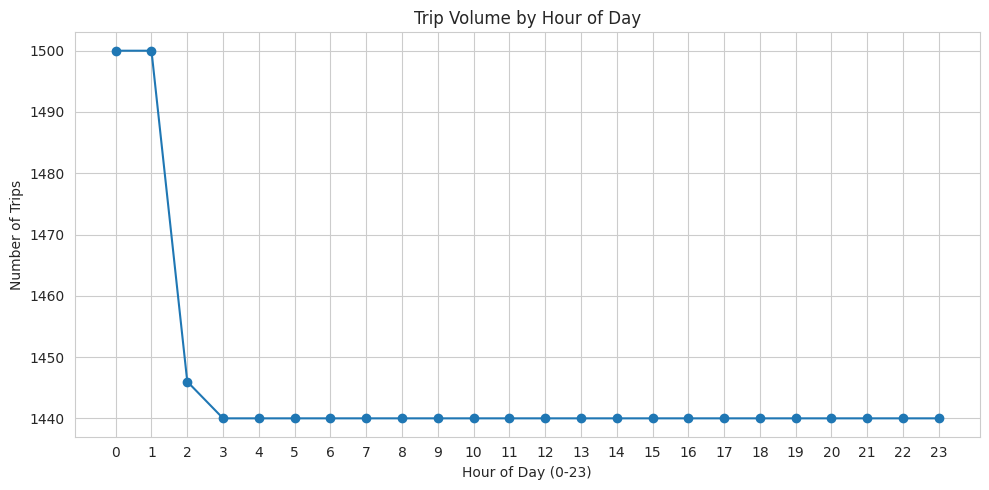

In [12]:
hourly_trips = df_clean.groupby('pickup_hour').size()

fig, ax = plt.subplots()
hourly_trips.plot(kind='line', marker='o', ax=ax, color='#1f77b4')
ax.set_title('Trip Volume by Hour of Day')
ax.set_xlabel('Hour of Day (0-23)')
ax.set_ylabel('Number of Trips')
ax.set_xticks(range(0,24))
plt.tight_layout()
plt.show()


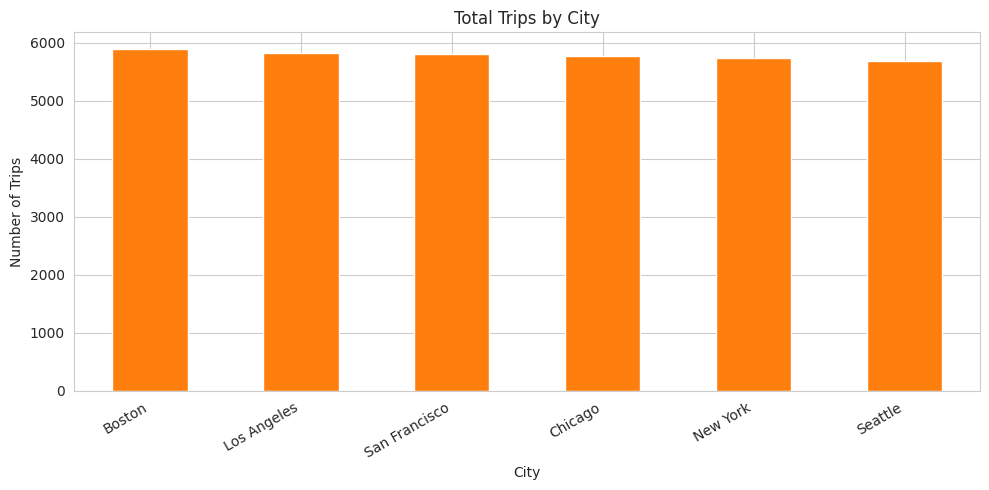

In [13]:
city_trips = df_clean['city'].value_counts()

fig, ax = plt.subplots()
city_trips.plot(kind='bar', ax=ax, color='#ff7f0e')
ax.set_title('Total Trips by City')
ax.set_xlabel('City')
ax.set_ylabel('Number of Trips')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


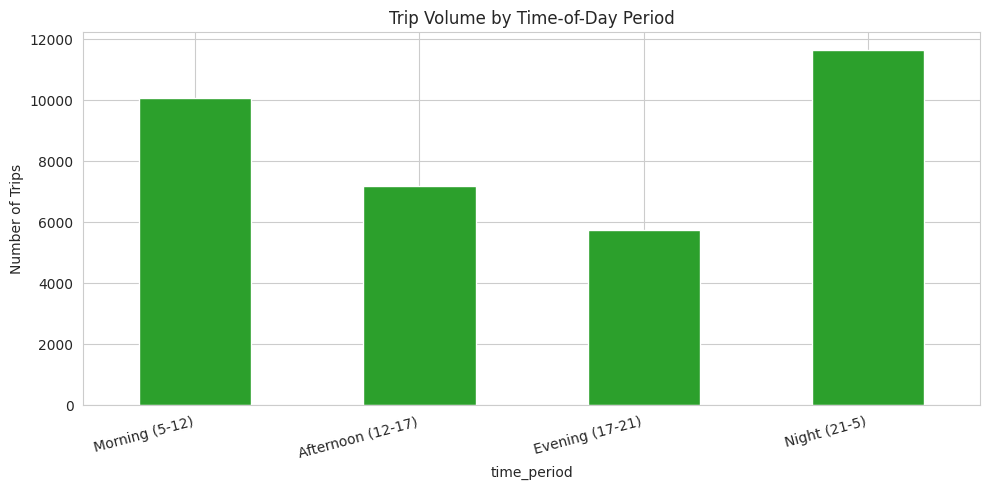

In [14]:
period_trips = df_clean['time_period'].value_counts().reindex(
    ['Morning (5-12)','Afternoon (12-17)','Evening (17-21)','Night (21-5)'])

fig, ax = plt.subplots()
period_trips.plot(kind='bar', ax=ax, color='#2ca02c')
ax.set_title('Trip Volume by Time-of-Day Period')
ax.set_ylabel('Number of Trips')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


In [15]:
completed_clean = df_clean[df_clean['status'] == 'Completed']

revenue_by_city = completed_clean.groupby('city')['fare_usd'].agg(['sum','mean','count']).sort_values('sum', ascending=False)
revenue_by_city.columns = ['total_revenue','avg_fare','completed_trips']
revenue_by_city


,total_revenue,avg_fare,completed_trips
city,,,
Boston,80640.50,16.070247,5018
New York,79551.52,16.136211,4930
San Francisco,78710.06,16.001232,4919
Seattle,78161.49,16.109128,4852
Los Angeles,77663.66,15.759671,4928
Chicago,77343.75,15.819953,4889


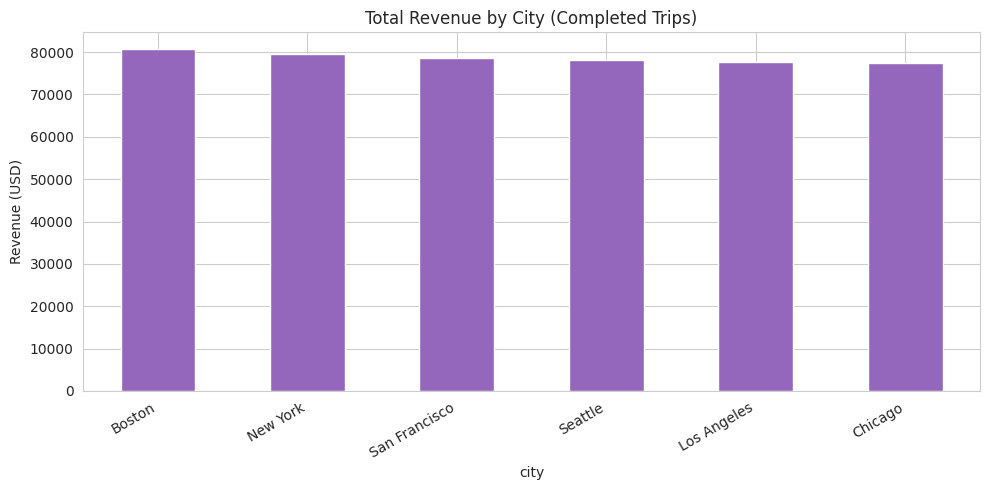

In [16]:
fig, ax = plt.subplots()
revenue_by_city['total_revenue'].plot(kind='bar', ax=ax, color='#9467bd')
ax.set_title('Total Revenue by City (Completed Trips)')
ax.set_ylabel('Revenue (USD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [17]:
revenue_by_payment = completed_clean.groupby('payment_method')['fare_usd'].agg(['sum','mean','count']).sort_values('sum', ascending=False)
revenue_by_payment.columns = ['total_revenue','avg_fare','completed_trips']
revenue_by_payment


,total_revenue,avg_fare,completed_trips
payment_method,,,
Card,118931.03,16.041412,7414
UPI,118524.76,15.958632,7427
Cash,117758.11,15.975866,7371
Wallet,116857.08,15.955363,7324


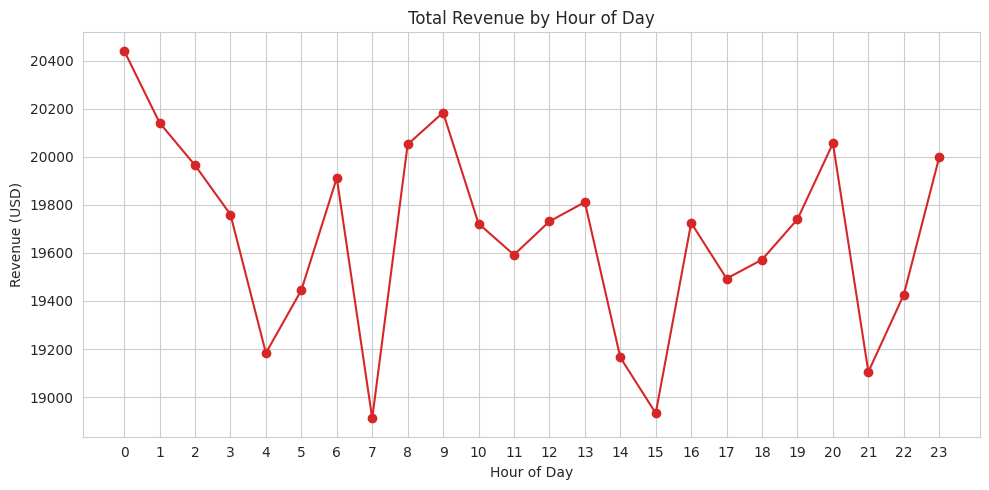

In [18]:
revenue_by_hour = completed_clean.groupby('pickup_hour')['fare_usd'].sum()

fig, ax = plt.subplots()
revenue_by_hour.plot(kind='line', marker='o', ax=ax, color='#d62728')
ax.set_title('Total Revenue by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Revenue (USD)')
ax.set_xticks(range(0,24))
plt.tight_layout()
plt.show()


### 2.3 Cancellation & No-Show Analysis

Overall status breakdown (%):
status
Completed    85.15
Cancelled     9.89
No-Show       4.96
Name: proportion, dtype: float64


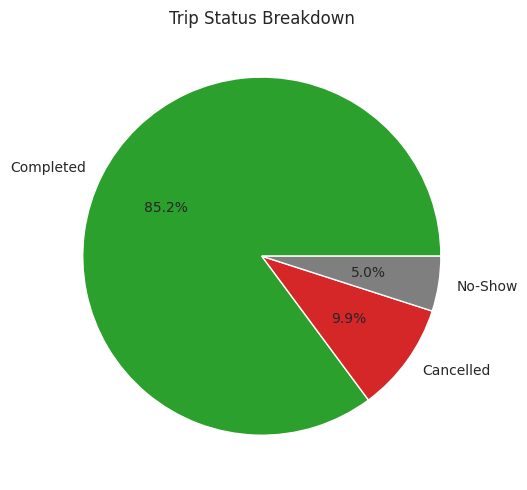

In [19]:
status_overall = df_clean['status'].value_counts(normalize=True) * 100
print("Overall status breakdown (%):")
print(status_overall.round(2))

fig, ax = plt.subplots()
df_clean['status'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax,
                                        colors=['#2ca02c','#d62728','#7f7f7f'])
ax.set_ylabel('')
ax.set_title('Trip Status Breakdown')
plt.tight_layout()
plt.show()


In [20]:
completion_by_city = df_clean.groupby('city')['status'].value_counts(normalize=True).unstack() * 100
completion_by_city = completion_by_city[['Completed','Cancelled','No-Show']].sort_values('Completed')
completion_by_city


status,Completed,Cancelled,No-Show
city,,,
San Francisco,84.766500,9.960365,5.273135
Los Angeles,84.790089,9.944942,5.264969
Chicago,84.819570,10.166551,5.013879
Boston,85.311119,9.962598,4.726284
Seattle,85.332395,9.883925,4.783679
New York,85.903468,9.409305,4.687228


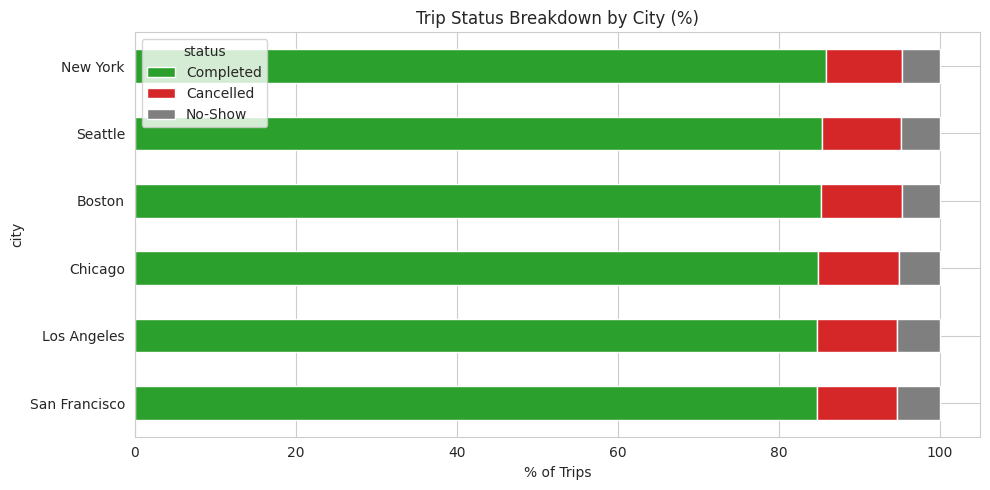

In [21]:
fig, ax = plt.subplots()
completion_by_city.plot(kind='barh', stacked=True, ax=ax,
                         color=['#2ca02c','#d62728','#7f7f7f'])
ax.set_title('Trip Status Breakdown by City (%)')
ax.set_xlabel('% of Trips')
plt.tight_layout()
plt.show()


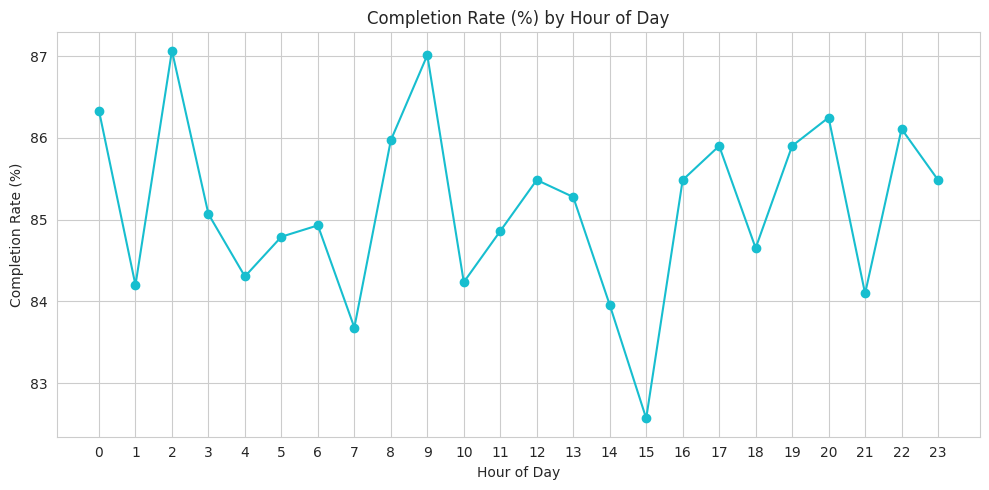

In [22]:
completion_by_hour = df_clean.groupby('pickup_hour')['status'].apply(
    lambda s: (s == 'Completed').mean() * 100
)

fig, ax = plt.subplots()
completion_by_hour.plot(kind='line', marker='o', ax=ax, color='#17becf')
ax.set_title('Completion Rate (%) by Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Completion Rate (%)')
ax.set_xticks(range(0,24))
plt.tight_layout()
plt.show()


In [23]:
cancellation_by_payment = df_clean.groupby('payment_method')['status'].value_counts(normalize=True).unstack() * 100
cancellation_by_payment[['Completed','Cancelled','No-Show']].sort_values('Completed')


status,Completed,Cancelled,No-Show
payment_method,,,
UPI,84.783105,10.525114,4.691781
Card,85.081478,9.605233,5.313289
Wallet,85.281789,9.827667,4.890545
Cash,85.470779,9.589518,4.939703


### 2.4 Driver & Rider Behavior

count    8810.000000
mean        3.937117
std         1.896252
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        13.000000
dtype: float64


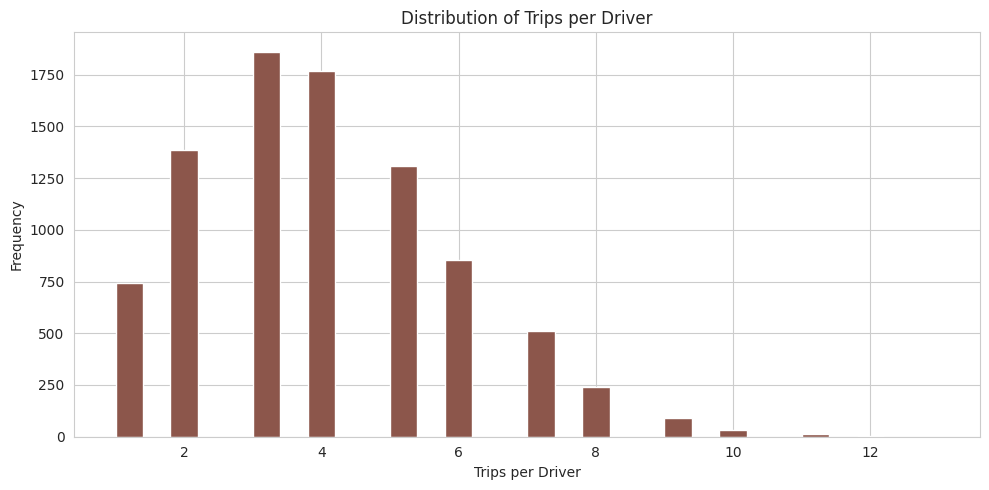

In [24]:
trips_per_driver = df_clean.groupby('driver_id').size()
print(trips_per_driver.describe())

fig, ax = plt.subplots()
trips_per_driver.plot(kind='hist', bins=30, ax=ax, color='#8c564b')
ax.set_title('Distribution of Trips per Driver')
ax.set_xlabel('Trips per Driver')
plt.tight_layout()
plt.show()


In [25]:
top_drivers = df_clean[df_clean['status']=='Completed'].groupby('driver_id')['fare_usd'].agg(['sum','count']).sort_values('sum', ascending=False).head(10)
top_drivers.columns = ['total_revenue','completed_trips']
top_drivers


,total_revenue,completed_trips
driver_id,,
3261,207.43,11
3256,191.24,10
9017,189.38,9
6599,180.89,10
9199,180.75,9
2561,180.56,9
6243,178.03,10
4718,177.81,9
1531,173.29,9


In [26]:
trips_per_rider = df_clean.groupby('rider_id').size()
repeat_riders = (trips_per_rider > 1).sum()
print(f"Total unique riders: {df_clean['rider_id'].nunique():,}")
print(f"Riders with more than 1 trip: {repeat_riders:,} ({repeat_riders/df_clean['rider_id'].nunique()*100:.1f}%)")
print(trips_per_rider.describe())


Total unique riders: 28,665
Riders with more than 1 trip: 5,265 (18.4%)
count    28665.000000
mean         1.210047
std          0.474228
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          5.000000
dtype: float64


## 3. Business Questions

Now we tie the EDA together into direct, decision-ready answers.


**Q1: Which city generates the most revenue — per trip, and per driver?**

In [27]:
drivers_per_city = df_clean.groupby('city')['driver_id'].nunique()
q1 = revenue_by_city.copy()
q1['drivers_in_city'] = drivers_per_city
q1['revenue_per_driver'] = (q1['total_revenue'] / q1['drivers_in_city']).round(2)
q1.sort_values('revenue_per_driver', ascending=False)


,total_revenue,avg_fare,completed_trips,drivers_in_city,revenue_per_driver
city,,,,,
New York,79551.52,16.136211,4930,4204,18.92
Seattle,78161.49,16.109128,4852,4170,18.74
Boston,80640.50,16.070247,5018,4305,18.73
San Francisco,78710.06,16.001232,4919,4249,18.52
Chicago,77343.75,15.819953,4889,4273,18.10
Los Angeles,77663.66,15.759671,4928,4339,17.90


**Q2: When (which hours, in which cities) should Uber allocate more drivers?** — looking at demand volume alongside completion rate to spot under-served, high-demand windows.

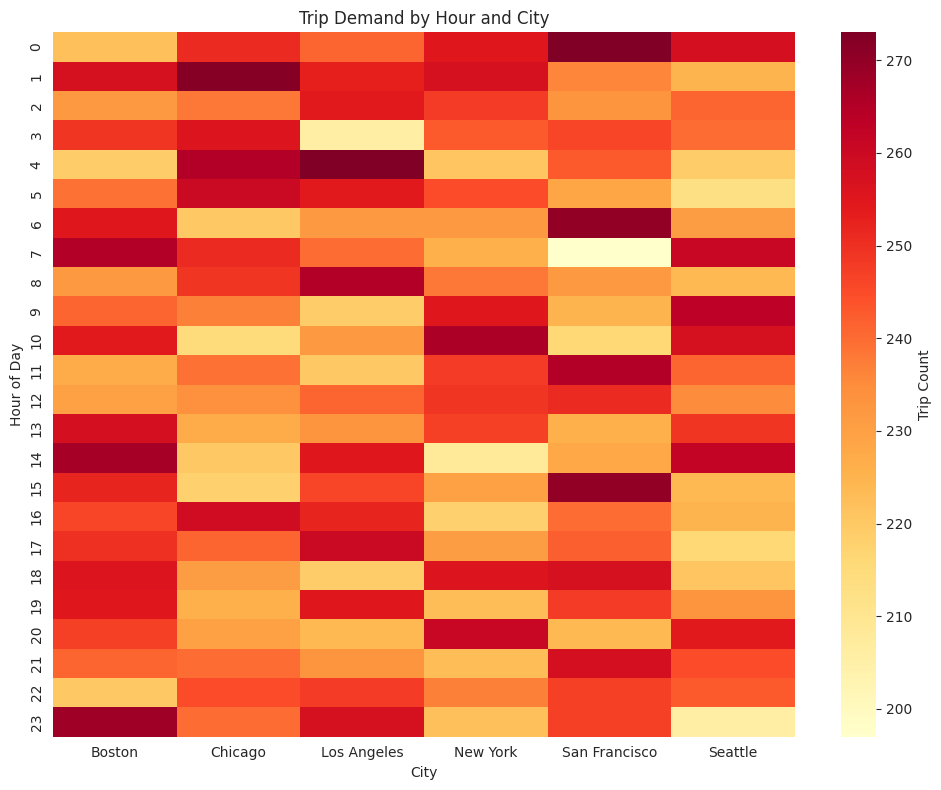

In [28]:
demand_heat = df_clean.pivot_table(index='pickup_hour', columns='city', values='trip_id', aggfunc='count')

fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(demand_heat, cmap='YlOrRd', ax=ax, cbar_kws={'label':'Trip Count'})
ax.set_title('Trip Demand by Hour and City')
ax.set_xlabel('City')
ax.set_ylabel('Hour of Day')
plt.tight_layout()
plt.show()


In [29]:
# Combine demand (volume) with completion rate to flag hours that are both busy AND under-served
demand_by_hour_city = df_clean.groupby(['city','pickup_hour']).size().rename('trip_count')
completion_by_hour_city = df_clean.groupby(['city','pickup_hour'])['status'].apply(lambda s: (s=='Completed').mean()*100).rename('completion_rate_pct')

driver_alloc = pd.concat([demand_by_hour_city, completion_by_hour_city], axis=1).reset_index()
# High demand (top 25%) + low completion rate (bottom 25%) = priority windows for more driver supply
high_demand_thresh = driver_alloc['trip_count'].quantile(0.75)
low_completion_thresh = driver_alloc['completion_rate_pct'].quantile(0.25)

priority_windows = driver_alloc[
    (driver_alloc['trip_count'] >= high_demand_thresh) &
    (driver_alloc['completion_rate_pct'] <= low_completion_thresh)
].sort_values('trip_count', ascending=False)

print("Priority hour/city windows for additional driver supply (high demand + low completion):")
priority_windows.head(15)


Priority hour/city windows for additional driver supply (high demand + low completion):


,city,pickup_hour,trip_count,completion_rate_pct
52,Los Angeles,4,273,81.684982
25,Chicago,1,272,83.455882
111,San Francisco,15,270,79.259259
28,Chicago,4,265,82.264151
107,San Francisco,11,265,83.018868
134,Seattle,14,262,81.679389
127,Seattle,7,261,83.524904
18,Boston,18,256,82.031250
6,Boston,6,255,80.392157
67,Los Angeles,19,255,81.176471


In [30]:
cancel_rate_by_hour = df_clean.groupby('pickup_hour')['status'].apply(lambda s: (s != 'Completed').mean()*100)
cancel_rate_by_city = df_clean.groupby('city')['status'].apply(lambda s: (s != 'Completed').mean()*100).sort_values(ascending=False)
cancel_rate_by_payment = df_clean.groupby('payment_method')['status'].apply(lambda s: (s != 'Completed').mean()*100).sort_values(ascending=False)

print("Non-completion rate (Cancelled + No-Show) by city (%):")
print(cancel_rate_by_city.round(2))
print("\nNon-completion rate by payment method (%):")
print(cancel_rate_by_payment.round(2))
print(f"\nNon-completion rate range across hours: {cancel_rate_by_hour.min():.2f}% - {cancel_rate_by_hour.max():.2f}%")


Non-completion rate (Cancelled + No-Show) by city (%):
city
San Francisco    15.23
Los Angeles      15.21
Chicago          15.18
Boston           14.69
Seattle          14.67
New York         14.10
Name: status, dtype: float64

Non-completion rate by payment method (%):
payment_method
UPI       15.22
Card      14.92
Wallet    14.72
Cash      14.53
Name: status, dtype: float64

Non-completion rate range across hours: 12.93% - 17.43%


**Q4: Which payment method correlates with higher/lower fares or cancellation rates?**

In [31]:
payment_summary = completed_clean.groupby('payment_method')['fare_usd'].agg(['mean','median','count'])
payment_summary['non_completion_rate_pct'] = cancel_rate_by_payment
payment_summary.columns = ['avg_fare','median_fare','completed_trips','non_completion_rate_pct']
payment_summary.sort_values('avg_fare', ascending=False)


,avg_fare,median_fare,completed_trips,non_completion_rate_pct
payment_method,,,,
Card,16.041412,15.535,7414,14.918522
Cash,15.975866,15.370,7371,14.529221
UPI,15.958632,15.430,7427,15.216895
Wallet,15.955363,15.430,7324,14.718211


In [33]:
# Download the cleaned CSV
# - In Google Colab, this triggers a browser download automatically.
# - In local Jupyter Notebook/Lab, this displays a clickable link that downloads the file.
try:
    from google.colab import files
    files.download('output/uber_trips_cleaned.csv')
except ImportError:
    from IPython.display import FileLink
    display(FileLink('output/uber_trips_cleaned.csv'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>